# 20 — Molecular dynamics: Lennard-Jones forces with a MeshGraphNet

Molecular dynamics is the Lagrangian particle problem at its purest: no mesh,
no persistent connectivity, and interactions that exist only within a cutoff
radius — inside a **periodic box**, so the two atoms nearest each other may sit
on opposite sides of the domain.

NVIDIA's own `examples/molecular_dynamics/lennard_jones` trains the generic
`physicsnemo.models.meshgraphnet.MeshGraphNet` on (positions → forces) frames.
No "molecular" architecture exists upstream and none is needed; what this
bridge had to grow was the **minimum-image neighbour search** — the
`"box_size"` key of `particle_bridge`'s connectivity block.

This notebook runs the recipe end to end:

- a velocity-Verlet reference integrator (`utilities.lennard_jones_reference`),
  whose Störmer-Verlet recurrence makes the dataset's central-difference
  targets **equal the reference forces to round-off**;
- the periodic radius graph, checked against a pair straddling the boundary;
- a `MeshGraphNet` trained on per-atom force, and a second one on per-atom
  potential energy — the two halves of a learned force field;
- deployment on a Kratos node cloud through `ParticleInferenceProcess`,
  asserting the trained model beats the mean-force predictor.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo          # optional runtime dependencies
> pip install torch_geometric torch_scatter     # additionally needed for MeshGraphNet
> pip install pyvista                           # for the atom render at the end
> ```
>
> Everything below runs on CPU; outputs are written to `./output/`.

In [1]:
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.PhysicsNeMoApplication  # registers the application
from KratosMultiphysics.PhysicsNeMoApplication.bridges import particle_bridge, graph_bridge
from KratosMultiphysics.PhysicsNeMoApplication.training import training_utils
from KratosMultiphysics.PhysicsNeMoApplication.training.torch_dataset import (
    CreateParticleTrajectoryDataset, MakeNormalizationCardEntries)
from KratosMultiphysics.PhysicsNeMoApplication.utilities import lennard_jones_reference as lj
from physicsnemo.models.meshgraphnet import MeshGraphNet

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)
print("torch", torch.__version__)

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.13.0+cu130


## The reference trajectory

`GenerateTrajectory` places `atoms_per_side³` atoms on a simple cubic lattice,
gives them Maxwell-Boltzmann velocities with **zero total momentum**, and
integrates velocity Verlet under the cutoff-shifted 12-6 potential with
minimum-image forces. It returns the positions, velocities, per-atom forces and
per-atom potential energies of every frame — the forces come from the
integrator itself rather than being recomputed afterwards.

Energy conservation is the integrator's own acceptance test: a symplectic
scheme does not drift.

64 atoms, 26 frames, box [6. 6. 6.], dt 0.005
relative energy drift over the trajectory: 3.52e-06
largest total-momentum component (mass 1): 6.38e-15


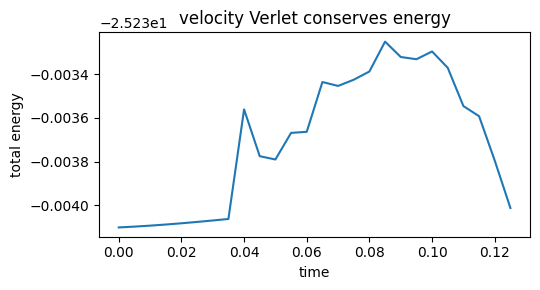

In [2]:
trajectory = lj.GenerateTrajectory(atoms_per_side=4, steps=26, dt=0.005, seed=0)
box, dt = trajectory["box_size"], trajectory["dt"]
positions, forces = trajectory["positions"], trajectory["forces"]
print(f"{positions.shape[1]} atoms, {positions.shape[0]} frames, box {box}, dt {dt}")

energies = numpy.array([lj.ComputeEnergy(p, v, box)
                        for p, v in zip(positions, trajectory["velocities"])])
drift = abs(energies[-1] - energies[0]) / abs(energies[0])
momentum = numpy.abs(trajectory["velocities"].sum(axis=1)).max()
print(f"relative energy drift over the trajectory: {drift:.2e}")
print(f"largest total-momentum component (mass 1): {momentum:.2e}")

plt.figure(figsize=(5.5, 3))
plt.plot(numpy.arange(len(energies)) * dt, energies)
plt.xlabel("time"); plt.ylabel("total energy"); plt.title("velocity Verlet conserves energy")
plt.tight_layout(); plt.show()

## The periodic graph

`particle_bridge.BuildParticleGraphFromPositions` returns exactly
`graph_bridge.BuildGraph`'s contract — `edge_index (2, E)` bidirectional and
`edge_features (E, 4)`, the relative position plus the distance — so the whole
graph toolchain applies unchanged.

With `"box_size"` set, the neighbour search is **minimum image**: the pair below
sits 0.1 apart *through* the boundary of a box of 1.0, at a direct distance of
0.9. Without the box they are not neighbours at all; with it they are linked,
and the edge vector is the short one.

In [3]:
straddling = numpy.array([[0.05, 0.5, 0.5], [0.95, 0.5, 0.5], [0.5, 0.5, 0.5]])
periodic, periodic_features = particle_bridge.BuildParticleGraphFromPositions(
    straddling, Kratos.Parameters('{"type": "radius", "radius": 0.2, "box_size": [1.0]}'))
open_space, _ = particle_bridge.BuildParticleGraphFromPositions(
    straddling, Kratos.Parameters('{"type": "radius", "radius": 0.2}'))
print(f"periodic: {periodic.shape[1]} directed edges, distance {periodic_features[0, 3]:.3f}")
print(f"open space: {open_space.shape[1]} edges")
assert periodic.shape[1] == 2 and open_space.shape[1] == 0

# the radius graph of one real frame, at the usual 2.5 sigma cutoff
CONNECTIVITY = '{"type": "radius", "radius": 2.5, "box_size": [6.0], "backend": "auto"}'
edge_index, edge_features = particle_bridge.BuildParticleGraphFromPositions(
    positions[0], Kratos.Parameters(CONNECTIVITY))
print(f"frame 0: {edge_index.shape[1]} directed edges, "
      f"{edge_index.shape[1] / positions.shape[1]:.1f} neighbours per atom")
print(f"largest edge-vector component {numpy.abs(edge_features[:, :3]).max():.3f} "
      f"(<= the 2.5 cutoff: every edge is a minimum image, not a wrapped one)")

periodic: 2 directed edges, distance 0.100
open space: 0 edges
frame 0: 1152 directed edges, 18.0 neighbours per atom
largest edge-vector component 1.500 (<= the 2.5 cutoff: every edge is a minimum image, not a wrapped one)


## Windowing into training pairs

`CreateParticleTrajectoryDataset` finite-differences positions into velocity
windows (oldest first) and central-difference acceleration targets. Here is the
fact that makes this dataset exact rather than approximate: velocity Verlet
**is** the Störmer-Verlet recurrence

$$x_{t+1} - 2x_t + x_{t-1} = \Delta t^2\, a_t,$$

so the targets the dataset computes are the integrator's own forces (mass 1) to
round-off. These are labels with no discretization error in them.

In [4]:
HISTORY = 2
dataset = CreateParticleTrajectoryDataset(positions, history_size=HISTORY,
                                          delta_time=dt, normalize=True)
raw = CreateParticleTrajectoryDataset(positions, history_size=HISTORY, delta_time=dt)
numpy.testing.assert_allclose(raw[0][1].numpy(), forces[HISTORY], rtol=1e-6, atol=1e-8)
print(f"{len(dataset)} samples; the central-difference targets equal the reference "
      f"forces to {numpy.abs(raw[0][1].numpy() - forces[HISTORY]).max():.2e}")

features, target = dataset[0]
print(f"features {tuple(features.shape)} (K={HISTORY} velocities, oldest first), "
      f"target {tuple(target.shape)}")
print("feature std per channel:", numpy.round(dataset.feature_std, 4))

23 samples; the central-difference targets equal the reference forces to 2.99e-11
features (64, 6) (K=2 velocities, oldest first), target (64, 3)
feature std per channel: [0.7612 0.6165 0.6616 0.7626 0.6175 0.6629]


## Training on per-atom force

Node features are the velocity history (`K·3 = 6` channels), edge features the
minimum-image relative position and distance (4 channels). The graph is rebuilt
per frame — the atoms move, so the neighbour list is not shared between samples.

loss 0.8660 -> 0.3756


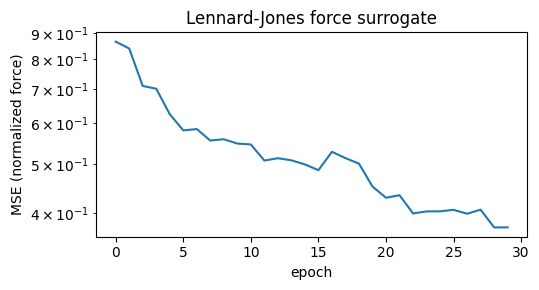

In [5]:
def BuildSamples(data, output=None):
    # (features, edge_features, PyG graph, target) per frame
    samples = []
    for i in range(len(data)):
        node_features, node_target = data[i]
        indices, edges = particle_bridge.BuildParticleGraphFromPositions(
            data.positions[i], Kratos.Parameters(CONNECTIVITY))
        samples.append((node_features, torch.from_numpy(edges),
                        graph_bridge.ToPyGGraph(indices, node_features.shape[0]),
                        node_target if output is None else output[i]))
    return samples


def MakeModel(output_dim, seed=0):
    torch.manual_seed(seed)
    return MeshGraphNet(input_dim_nodes=HISTORY * 3, input_dim_edges=4, output_dim=output_dim,
                        processor_size=2, hidden_dim_processor=16,
                        hidden_dim_node_encoder=16, hidden_dim_edge_encoder=16,
                        hidden_dim_node_decoder=16).double()


def Train(model, samples, epochs, lr=2e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(epochs):
        total = 0.0
        for node_features, edges, graph, node_target in samples:
            optimizer.zero_grad()
            loss = torch.nn.functional.mse_loss(model(node_features, edges, graph), node_target)
            loss.backward()
            optimizer.step()
            total += loss.item()
        history.append(total / len(samples))
    return history


samples = BuildSamples(dataset)
force_model = MakeModel(output_dim=3)
history = Train(force_model, samples, epochs=30)
print(f"loss {history[0]:.4f} -> {history[-1]:.4f}")

plt.figure(figsize=(5.5, 3))
plt.semilogy(history)
plt.xlabel("epoch"); plt.ylabel("MSE (normalized force)"); plt.title("Lennard-Jones force surrogate")
plt.tight_layout(); plt.show()

## Deployment on a Kratos node cloud

`ParticleInferenceProcess` rebuilds the periodic graph from the current node
positions every step, gathers the velocity history out of the solution-step
buffer, standardizes it with the card's `"input_normalization"`, runs the model,
de-normalizes the prediction with `"output_normalization"` and advances the
nodes with semi-implicit Euler.

Both halves of the standardization have to travel with the checkpoint —
`MakeNormalizationCardEntries` writes them — because the model was trained on
standardized velocity histories while the model part holds raw ones.

The window is fed over `history_size` steps, so the process sees `(v_{t-1}, v_t)`
exactly as the dataset built them.

In [6]:
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import particle_inference_process

checkpoint = OUTPUT / "lennard_jones_forces.mdlus"
card = {"input_fields": [{"variable_name": "VELOCITY", "data_location": "node_historical"}],
        "output_fields": [{"variable_name": "ACCELERATION", "data_location": "node_historical"}],
        "history_size": HISTORY, "connectivity": {"radius": 2.5, "box_size": [6.0]}}
card.update(MakeNormalizationCardEntries(dataset))
training_utils.SaveTrainedModel(force_model, checkpoint, card=card)

frame = 12
kratos_model = Kratos.Model()
atoms = kratos_model.CreateModelPart("Atoms")
for variable in (Kratos.VELOCITY, Kratos.ACCELERATION, Kratos.DISPLACEMENT):
    atoms.AddNodalSolutionStepVariable(variable)
atoms.SetBufferSize(2)
for i, xyz in enumerate(positions[frame]):
    atoms.CreateNewNode(i + 1, *[float(c) for c in xyz])
atoms.ProcessInfo[Kratos.DELTA_TIME] = dt

process = particle_inference_process.Factory(Kratos.Parameters('''{
    "Parameters": {
        "model_part_name" : "Atoms",
        "model_settings"  : { "checkpoint_file" : "%s", "checkpoint_type" : "physicsnemo",
                              "device" : "cpu" },
        "model_interface" : "meshgraphnet",
        "connectivity"    : %s,
        "history_size"    : %d
    }
}''' % (checkpoint, CONNECTIVITY, HISTORY)), kratos_model)

window = [(positions[frame - 1] - positions[frame - 2]) / dt,
          (positions[frame] - positions[frame - 1]) / dt]
for step, velocity in enumerate(window, start=1):
    for i, node in enumerate(atoms.Nodes):
        node.SetSolutionStepValue(Kratos.VELOCITY, [float(c) for c in velocity[i]])
    atoms.ProcessInfo[Kratos.STEP] = step
    process.ExecuteFinalizeSolutionStep()

predicted = numpy.array([node.GetSolutionStepValue(Kratos.ACCELERATION) for node in atoms.Nodes])
reference = forces[frame]
error = numpy.sqrt(numpy.mean((predicted - reference) ** 2))
baseline = numpy.sqrt(numpy.mean((reference - reference.mean(axis=0)) ** 2))
print(f"deployed force RMSE   {error:.4f}")
print(f"mean-force predictor  {baseline:.4f}   ({baseline / error:.2f}x worse)")
assert error < baseline, "the deployed model must beat predicting the mean force everywhere"

deployed force RMSE   0.1716
mean-force predictor  0.3633   (2.12x worse)


The comparison is the honest one for a force field: a model that ignored its
(de-normalized) inputs could still predict the mean force everywhere, and that
baseline is what beating the data actually means here. The atoms also moved —
unwrapped, which the periodic graph does not mind, because it takes positions
modulo the box before searching.

In [7]:
moved = numpy.abs(numpy.array([node.X for node in atoms.Nodes]) - positions[frame][:, 0]).max()
inside = bool(numpy.all([0.0 <= node.X < 6.0 for node in atoms.Nodes]))
print(f"largest x displacement after two steps: {moved:.3e}")
print(f"every node still inside [0, 6) without rewrapping: {inside}")

largest x displacement after two steps: 7.949e-03
every node still inside [0, 6) without rewrapping: True


## The other half of a force field: per-atom potential energy

Forces are the gradient half; the energy half is a scalar per atom, regressed
on the same graphs with a one-channel head. Together they are what a learned
force field has to produce.

loss 0.9715 -> 0.5669


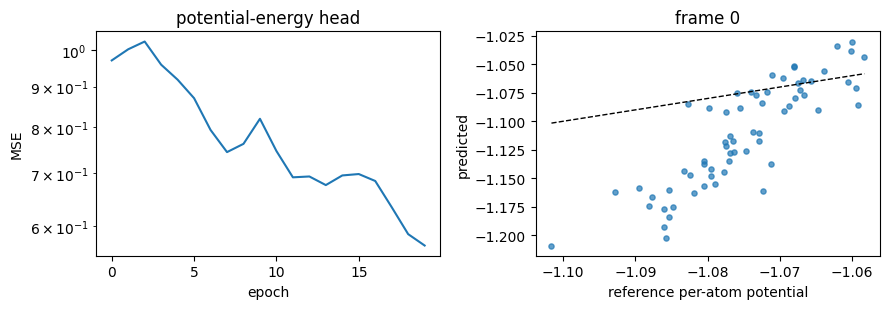

In [8]:
potential = trajectory["potential"][HISTORY:HISTORY + len(dataset)]
mean, std = potential.mean(), potential.std()
energy_targets = [torch.from_numpy((potential[i] - mean) / std)[:, None] for i in range(len(dataset))]

energy_model = MakeModel(output_dim=1, seed=1)
energy_history = Train(energy_model, BuildSamples(dataset, energy_targets), epochs=20)
print(f"loss {energy_history[0]:.4f} -> {energy_history[-1]:.4f}")

with torch.no_grad():
    node_features, edges, graph, _ = BuildSamples(dataset, energy_targets)[0]
    predicted_energy = energy_model(node_features, edges, graph).numpy().ravel() * std + mean
reference_energy = potential[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].semilogy(energy_history)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE"); axes[0].set_title("potential-energy head")
axes[1].scatter(reference_energy, predicted_energy, s=14, alpha=0.7)
limits = [reference_energy.min(), reference_energy.max()]
axes[1].plot(limits, limits, "k--", lw=1)
axes[1].set_xlabel("reference per-atom potential"); axes[1].set_ylabel("predicted")
axes[1].set_title("frame 0")
plt.tight_layout(); plt.show()

### The atoms

The cloud at the deployed frame, atoms coloured by reference per-atom potential
energy, with the periodic box drawn around them. Atoms deep in the well sit in
the crowded neighbourhoods the initial lattice has melted into by this frame.

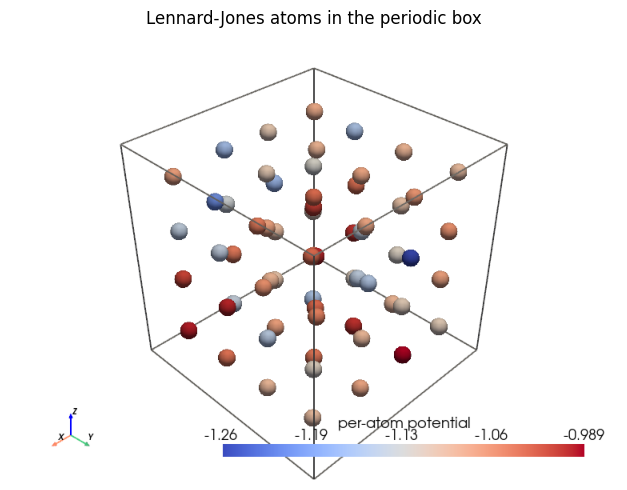

In [9]:
import pyvista as pv

cloud = pv.PolyData(positions[frame])
cloud["potential"] = trajectory["potential"][frame]
plotter = pv.Plotter(off_screen=True, window_size=(760, 560))
plotter.add_mesh(cloud, scalars="potential", cmap="coolwarm", point_size=22,
                 render_points_as_spheres=True, scalar_bar_args={"title": "per-atom potential"})
plotter.add_mesh(pv.Box(bounds=(0.0, 6.0, 0.0, 6.0, 0.0, 6.0)), style="wireframe",
                 color="grey", line_width=2)
plotter.add_axes(); plotter.view_isometric()
img = plotter.screenshot(None)

plt.figure(figsize=(7, 5)); plt.imshow(img); plt.axis("off")
plt.title("Lennard-Jones atoms in the periodic box")
plt.tight_layout(); plt.savefig(str(OUTPUT / "lennard_jones_atoms.png"), dpi=120, bbox_inches="tight")
plt.show()

## Takeaways

- The gap between Kratos and molecular dynamics was never the architecture —
  the generic `MeshGraphNet` is what NVIDIA's own example uses. It was the
  **periodic neighbour search**, now `particle_bridge`'s `"box_size"`: minimum
  image, exact, with a `scipy` `cKDTree` fast path and a brute-force fallback
  that agrees with it edge for edge.
- Train targets and deployment integrator must share a discretization. Velocity
  Verlet's Störmer-Verlet recurrence makes `CreateParticleTrajectoryDataset`'s
  central differences equal the reference forces to round-off, so the labels
  carry no scheme error.
- Write **both** normalization halves into the card. The model here was trained
  on standardized velocity histories and deployed on raw ones; without
  `"input_normalization"` the process would feed it data in the wrong units and
  the rollout would drift.
- Compare against a baseline that cannot use the inputs — the mean-force
  predictor — rather than against zero. It is the version of "better than
  nothing" that a force field can actually fail.